## Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch

import sys, os
sys.path.append(os.path.join(os.getcwd(), ".."))


from ml_force import MorrisLecar,MorrisLecarCurrent, z_transform, minmax_transform
from ml_force.supervisors import LorenzAttractor, VanDerPol
from ml_force.plots import plot_model
from scipy.signal import find_peaks

## Preparations for Lorenz Attractor

In [15]:
seed = 1
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.random.manual_seed(seed)

T = 10000
dt = 5e-2
t = np.arange(0, T, dt)
nt = t.size
# x = VanDerPol(T, dt, mu=1.5, tau=.02).generate(transient_time=500.0)
x = LorenzAttractor(T, dt, tau=.01).generate(transient_time=500.0)

x = x.T
# sup = minmax_transform(x, zero_mean=True)
sup = z_transform(x)
print(sup.shape)

(200000, 3)


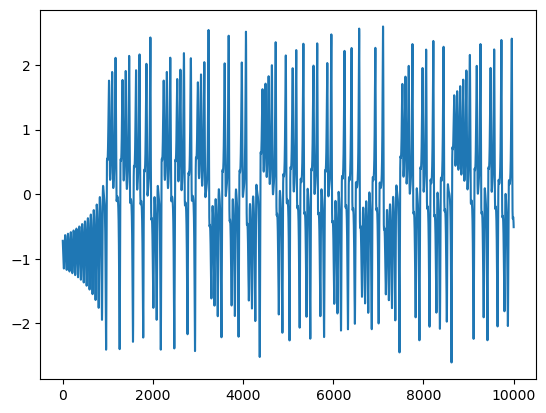

In [16]:
plt.plot(t, sup[:, 1])
plt.show()

## Set up params

In [17]:
NE = 200
NI = 200
N = NI + NE

# input current for I and E neurons
Ie = 75
Ii = 75
current = np.ones((N, 1))
middle = N // 2
current[:middle] *= Ie  # NE bias
current[middle:] *= Ii  # NI bias
# current = np.random.rand(N, 1) * Ie

Q = 100
# lamda = 8e-1
gbar = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

init_params = dict(N=N, BIAS=current, supervisor=sup, Q=Q, gbar=gbar, T=T, dt=dt, device=device)

cuda


In [18]:
render_params = dict(rls_start=500, 
                     rls_stop=T*.6, rls_step=20, l_ridge=0.,
                     live_plot=False, plt_interval=300,
                     n_neurons=10, save_all=False)

In [19]:
l_range = np.logspace(start=-5, stop=1., num=10, endpoint=True, base=10)
l_range

array([1.00000000e-05, 4.64158883e-05, 2.15443469e-04, 1.00000000e-03,
       4.64158883e-03, 2.15443469e-02, 1.00000000e-01, 4.64158883e-01,
       2.15443469e+00, 1.00000000e+01])

In [20]:
def run_mesh(Model:MorrisLecar, model_params:dict, render_params:dict, mesh:dict[str, np.ndarray]):
    results = dict()
    
    for key, value in mesh.items():
        decs = []
        vols = []
        preds = []
        for i in range(len(value)):
            print(f"Running mesh for {key}={value[i]}")
            init_params = model_params | {key: value[i]}
            model = Model(**init_params)
            try:
                _, v_trace, dec_trace = model.render(**render_params)
            except Exception as e:
                print(e)
            decs.append(dec_trace.cpu().numpy())
            vols.append(v_trace.cpu().numpy())
            preds.append(model.x_hat_rec.cpu().numpy())
        result = {"decoders": decs, "voltage_traces": vols, 'output': preds}
        results[key] = result
    return results

In [21]:
mesh = {'l':l_range}

results = run_mesh(MorrisLecar, init_params, render_params, mesh)

Running mesh for l=1e-05


  0%|          | 0/200000 [00:00<?, ?it/s]

 64%|██████▎   | 127064/200000 [00:44<00:25, 2839.39it/s]


Error encountered. Looped stopped at iteration i=127064
NaN value encountered during iteration.
Running mesh for l=4.641588833612782e-05


 85%|████████▌ | 170256/200000 [01:00<00:10, 2831.62it/s]


...

100%|██████████| 200000/200000 [01:10<00:00, 2828.57it/s]


Running mesh for l=2.154434690031882


100%|██████████| 200000/200000 [01:10<00:00, 2843.19it/s]


Running mesh for l=10.0


100%|██████████| 200000/200000 [01:10<00:00, 2832.95it/s]


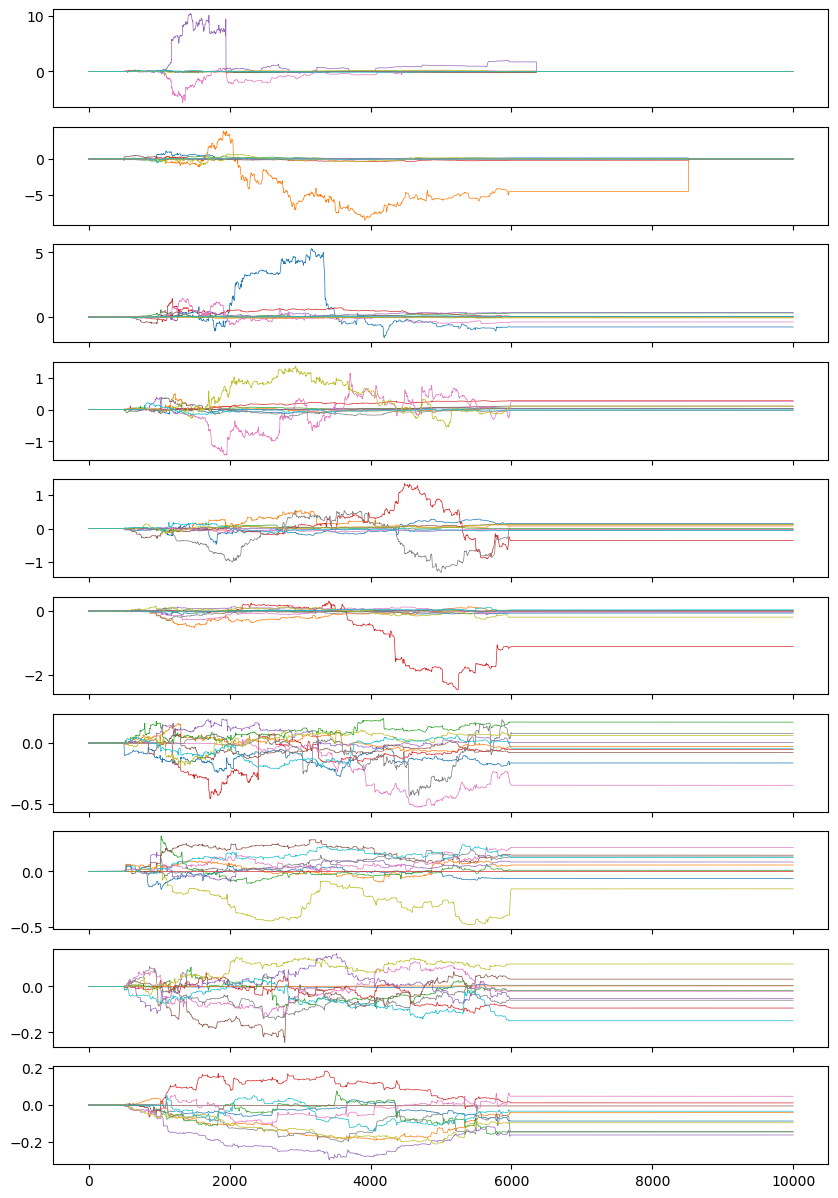

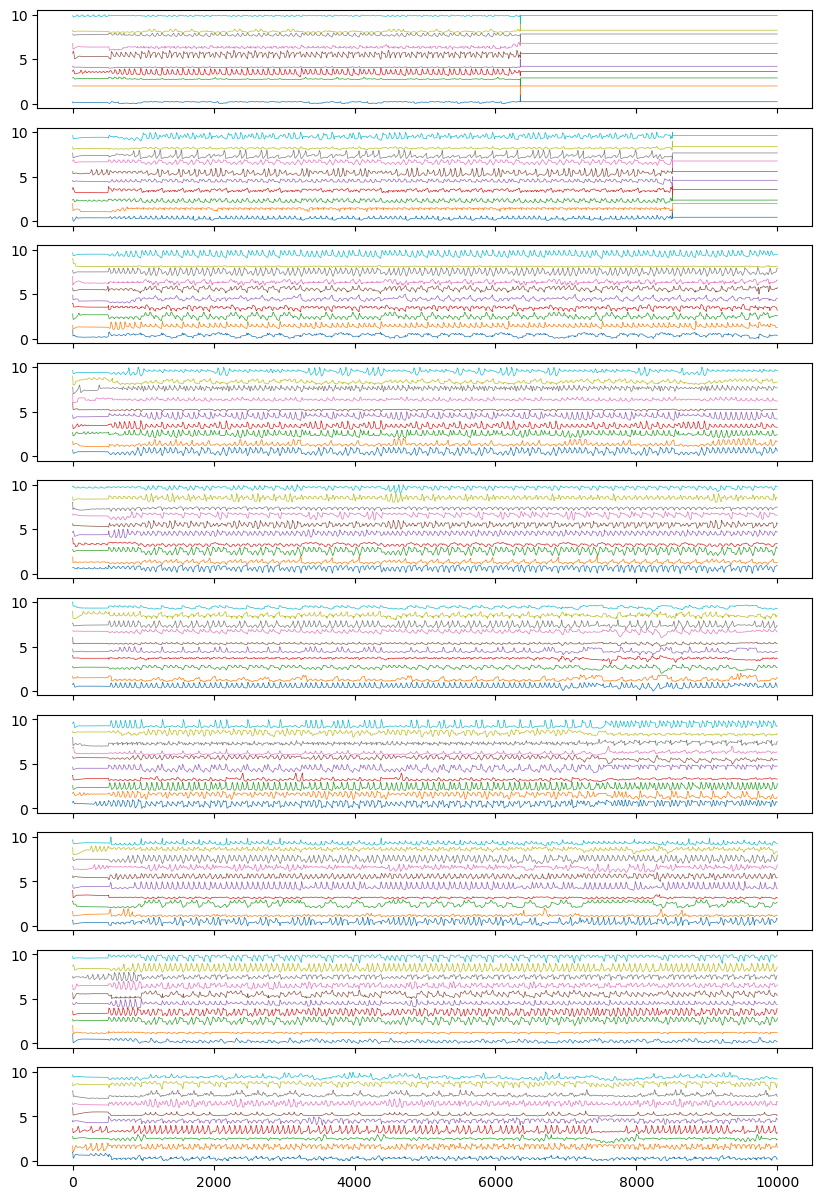

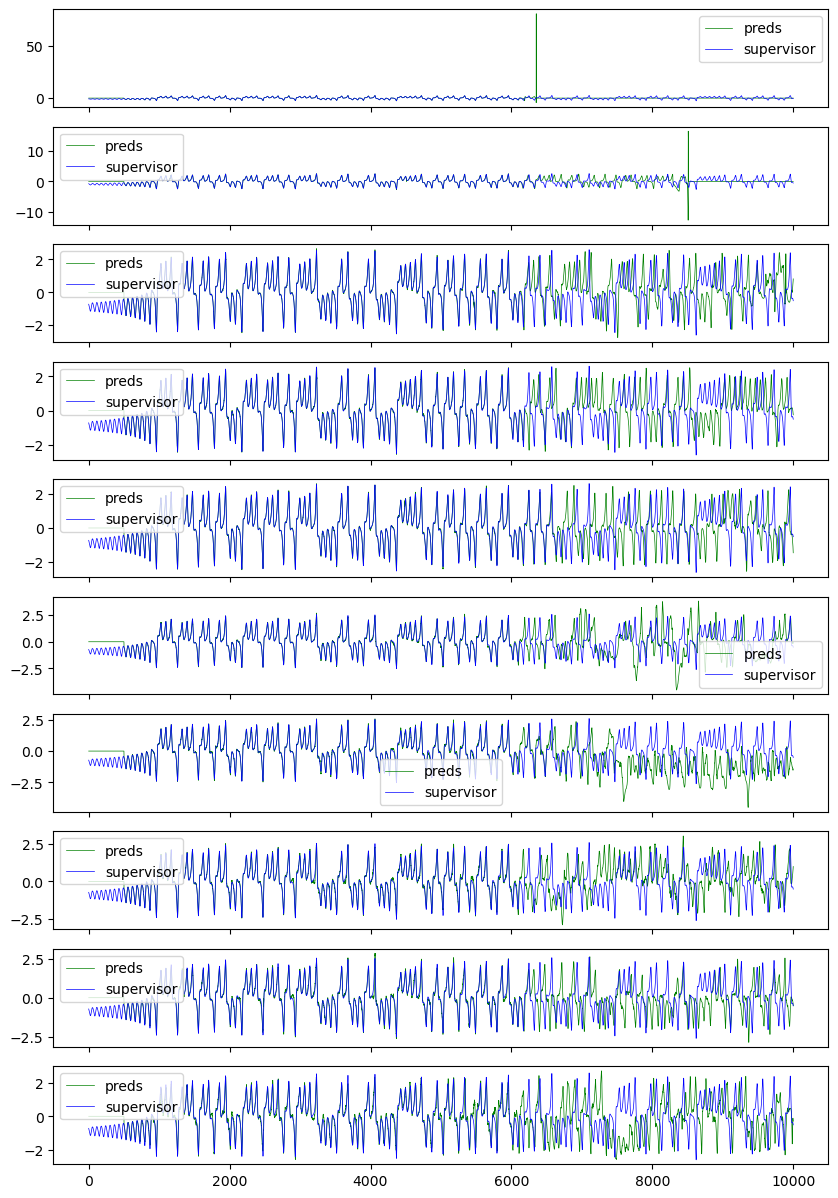

In [22]:
fig1, ax1 = plt.subplots(figsize=(10, 15), nrows=len(l_range), sharex=True)
fig2, ax2 = plt.subplots(figsize=(10, 15), nrows=len(l_range), sharex=True)
fig3, ax3 = plt.subplots(figsize=(10, 15), nrows=len(l_range), sharex=True)

lw = .5
output_ax = 1

for i in range(len(l_range)):
    v_trace = results['l']['voltage_traces'][i]
    dec_trace = results['l']['decoders'][i]
    xhat = results['l']['output'][i]
    # Plot decoders
    ax1[i].plot(t, dec_trace, lw=lw)
    # Plot voltage traces
    for j in range(v_trace.shape[1]):
        sig = v_trace[:, j]
        sig = (sig - sig.min()) / (sig.max() - sig.min()) + j
        ax2[i].plot(t, sig, lw=lw)
    # Plot reservoir output
    ax3[i].plot(t, xhat[:, output_ax], 'g-', lw=lw, label='preds')
    ax3[i].plot(t, sup[:, output_ax], 'b-', lw=lw, label='supervisor')
    ax3[i].legend(loc=0)
    
plt.show(fig1)
plt.show(fig2)
plt.show(fig3)